# Données

In [32]:
import pandas as pd
import numpy as np

# Données des produits
produits_data = {
    'produit_id': ['P001', 'P002', 'P003', 'P004', 'P005'],
    'nom_produit': ['Ordinateur Gaming', 'Smartphone Pro', 'Tablette Elite', 
                   'Casque Audio', 'Montre Connectée'],
    'categorie': ['Électronique', 'Électronique', 'Électronique', 
                 'Accessoire', 'Accessoire'],
    'prix_unitaire': [1299.99, 899.50, 549.99, 199.99, 299.99],
    'cout_production': [800.00, 550.00, 350.00, 120.00, 180.00]
}


# Données des ventes (octobre à décembre 2026)
np.random.seed(42)
dates = pd.date_range('2026-10-01', '2026-12-31', freq='D')
ventes_data = {
    'date_vente': np.random.choice(dates, 500),
    'produit_id': np.random.choice(['P001', 'P002', 'P003', 'P004', 'P005'], 500),
    'quantite': np.random.randint(1, 6, 500),
    'ville': np.random.choice(['Paris', 'Lyon', 'Marseille', 'Toulouse', 'Nice'], 500),
    'mode_paiement': np.random.choice(['Carte', 'PayPal', 'Virement'], 500),
    'client_id': np.random.randint(1000, 1100, 500)
}

# Données des clients
clients_data = {
    'client_id': list(range(1000, 1100)),
    'segment': np.random.choice(['Premium', 'Standard', 'Basic'], 100),
    'date_inscription': pd.date_range('2025-01-01', periods=100, freq='D'),
    'region': np.random.choice(['Nord', 'Sud', 'Est', 'Ouest'], 100)
}

# Partie 1

### 1️⃣ Création des DataFrames

In [5]:
import pandas as pd
import numpy as np

# Création des DataFrames
df_produits = pd.DataFrame(produits_data)
df_ventes = pd.DataFrame(ventes_data)
df_clients = pd.DataFrame(clients_data)

### 2️⃣ Vérification des valeurs manquantes

In [6]:
print("Valeurs manquantes - Produits :")
print(df_produits.isnull().sum())

print("\nValeurs manquantes - Ventes :")
print(df_ventes.isnull().sum())

print("\nValeurs manquantes - Clients :")
print(df_clients.isnull().sum())

Valeurs manquantes - Produits :
produit_id         0
nom_produit        0
categorie          0
prix_unitaire      0
cout_production    0
dtype: int64

Valeurs manquantes - Ventes :
date_vente       0
produit_id       0
quantite         0
ville            0
mode_paiement    0
client_id        0
dtype: int64

Valeurs manquantes - Clients :
client_id           0
segment             0
date_inscription    0
region              0
dtype: int64


Analyse attendue :

- Si toutes les valeurs sont à 0 -> dataset propre

- Sinon -> prévoir traitement (imputation ou suppression)

### 3️⃣ Conversion des dates en datetime

In [7]:
df_ventes['date_vente'] = pd.to_datetime(df_ventes['date_vente'])
df_clients['date_inscription'] = pd.to_datetime(df_clients['date_inscription'])

Vérification optionnelle :

In [8]:
print(df_ventes.dtypes)
print(df_clients.dtypes)

date_vente       datetime64[us]
produit_id                  str
quantite                  int32
ville                       str
mode_paiement               str
client_id                 int32
dtype: object
client_id                    int64
segment                        str
date_inscription    datetime64[us]
region                         str
dtype: object


### 4️⃣ Calcul de la marge unitaire

Formule :

marge = prix_unitaire - cout_production

In [9]:
df_produits['marge_unitaire'] = (
    df_produits['prix_unitaire'] - df_produits['cout_production']
)

Visualisation :

In [10]:
print(df_produits)

  produit_id        nom_produit     categorie  prix_unitaire  cout_production  \
0       P001  Ordinateur Gaming  Électronique        1299.99            800.0   
1       P002     Smartphone Pro  Électronique         899.50            550.0   
2       P003     Tablette Elite  Électronique         549.99            350.0   
3       P004       Casque Audio    Accessoire         199.99            120.0   
4       P005   Montre Connectée    Accessoire         299.99            180.0   

   marge_unitaire  
0          499.99  
1          349.50  
2          199.99  
3           79.99  
4          119.99  


# Partie 2

### 1️⃣ Chiffre d’affaires total du trimestre

👉 On doit d’abord joindre ventes + produits pour récupérer les prix.

In [11]:
# Jointure ventes + produits
df_merged = df_ventes.merge(df_produits, on='produit_id')

# Calcul du CA par ligne
df_merged['chiffre_affaires'] = df_merged['quantite'] * df_merged['prix_unitaire']

# CA total
ca_total = df_merged['chiffre_affaires'].sum()

print("CA total trimestre :", ca_total)

CA total trimestre : 989649.92


### 2️⃣ Top 3 produits les plus vendus (quantité)

In [13]:
top_produits = (
    df_merged.groupby('nom_produit')['quantite']
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

print(top_produits)

nom_produit
Montre Connectée     330
Ordinateur Gaming    327
Tablette Elite       306
Name: quantite, dtype: int32


👉 Résultat = produits avec le plus de volume (important pour stratégie commerciale).

### 3️⃣ Ville générant le plus de CA

In [14]:
ca_par_ville = (
    df_merged.groupby('ville')['chiffre_affaires']
    .sum()
    .sort_values(ascending=False)
)

print(ca_par_ville)
print("Top ville :", ca_par_ville.idxmax())

ville
Lyon         223223.85
Nice         207566.05
Toulouse     202869.08
Paris        186671.59
Marseille    169319.35
Name: chiffre_affaires, dtype: float64
Top ville : Lyon


👉 Permet d’identifier le marché le plus rentable.

### 4️⃣ Évolution du CA quotidien (visualisation)

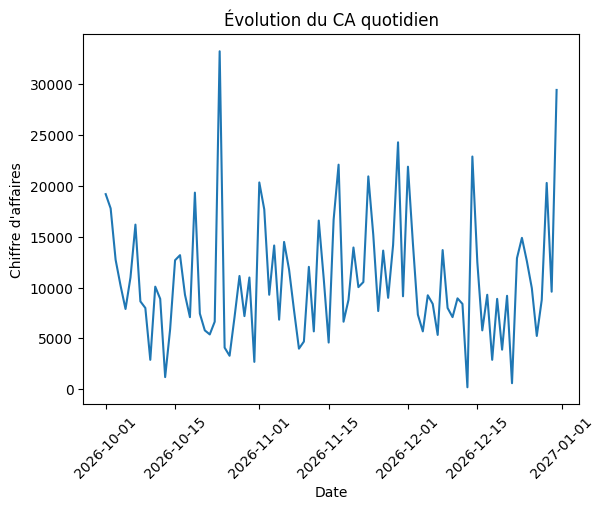

In [15]:
import matplotlib.pyplot as plt

ca_journalier = (
    df_merged.groupby('date_vente')['chiffre_affaires']
    .sum()
    .sort_index()
)

plt.figure()
plt.plot(ca_journalier)
plt.title("Évolution du CA quotidien")
plt.xlabel("Date")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=45)
plt.show()

👉 Lecture :

- pics = périodes fortes (week-end, promos…)

- creux = jours faibles

### 5️⃣ Mode de paiement le plus populaire

In [17]:
mode_paiement = (
    df_merged['mode_paiement']
    .value_counts()
)

print(mode_paiement)
print("Mode le plus utilisé :", mode_paiement.idxmax())

mode_paiement
PayPal      177
Carte       174
Virement    149
Name: count, dtype: int64
Mode le plus utilisé : PayPal


# Partie 3

### 1️⃣ Chiffre d’affaires mensuel

In [18]:
# Extraire le mois
df_merged['mois'] = df_merged['date_vente'].dt.to_period('M')

# CA mensuel
ca_mensuel = (
    df_merged.groupby('mois')['chiffre_affaires']
    .sum()
)

print(ca_mensuel)

mois
2026-10    307402.23
2026-11    363892.25
2026-12    318355.44
Freq: M, Name: chiffre_affaires, dtype: float64


### 2️⃣ Tendance avec moyenne mobile (7 jours)

In [19]:
ca_journalier = (
    df_merged.groupby('date_vente')['chiffre_affaires']
    .sum()
    .sort_index()
)

# Moyenne mobile
ca_journalier_mm7 = ca_journalier.rolling(window=7).mean()

Visualisation :

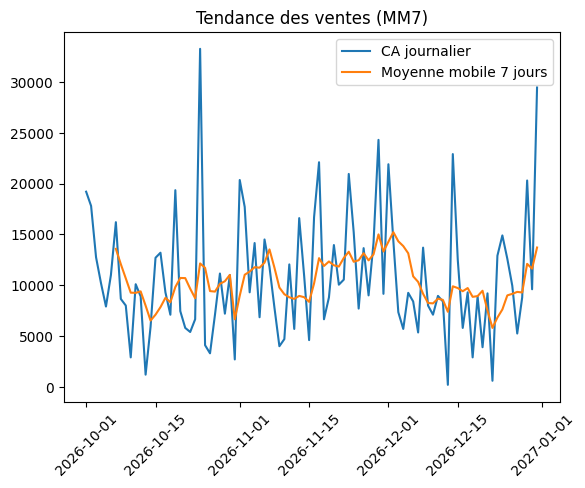

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(ca_journalier, label='CA journalier')
plt.plot(ca_journalier_mm7, label='Moyenne mobile 7 jours')
plt.legend()
plt.title("Tendance des ventes (MM7)")
plt.xticks(rotation=45)
plt.show()

👉 Lecture :

- Lisse les fluctuations

- Fait apparaître la vraie tendance

### 3️⃣ Panier moyen par ville

👉 Formule :

panier moyen = CA total / nombre de transactions

In [21]:
panier_moyen_ville = (
    df_merged.groupby('ville')
    .agg({
        'chiffre_affaires': 'sum',
        'date_vente': 'count'
    })
)

panier_moyen_ville['panier_moyen'] = (
    panier_moyen_ville['chiffre_affaires'] / panier_moyen_ville['date_vente']
)

print(panier_moyen_ville[['panier_moyen']])

           panier_moyen
ville                  
Lyon        2188.469118
Marseille   1820.638172
Nice        2034.961275
Paris       1964.964105
Toulouse    1878.417407


👉 Insight :

Compare le pouvoir d’achat ou comportement client selon villes

### 4️⃣ Clients les plus fidèles (> 5 achats)

In [22]:
clients_fideles = (
    df_merged.groupby('client_id')
    .size()
)

clients_fideles = clients_fideles[clients_fideles > 5]

print(clients_fideles)

client_id
1002    10
1003    11
1008     6
1013     6
1014     7
1015     7
1018     8
1019     8
1020    10
1023     8
1025     6
1029     7
1032     7
1033     6
1038     7
1040     6
1045     7
1046     8
1056     9
1057    10
1059     8
1060     6
1062     8
1063     6
1068     6
1069    13
1081     7
1084     8
1085     8
1087     6
1089     6
1090     6
1091     8
1097     7
1098     8
1099     6
dtype: int64


👉 Option enrichie :

In [23]:
# Ajouter infos clients
clients_fideles_detail = clients_fideles.reset_index().merge(df_clients, on='client_id')

print(clients_fideles_detail)

    client_id   0   segment date_inscription region
0        1002  10   Premium       2025-01-03  Ouest
1        1003  11  Standard       2025-01-04   Nord
2        1008   6  Standard       2025-01-09    Est
3        1013   6  Standard       2025-01-14  Ouest
4        1014   7  Standard       2025-01-15   Nord
5        1015   7     Basic       2025-01-16    Est
6        1018   8     Basic       2025-01-19    Sud
7        1019   8  Standard       2025-01-20  Ouest
8        1020  10     Basic       2025-01-21    Sud
9        1023   8     Basic       2025-01-24   Nord
10       1025   6   Premium       2025-01-26  Ouest
11       1029   7   Premium       2025-01-30    Sud
12       1032   7   Premium       2025-02-02   Nord
13       1033   6     Basic       2025-02-03   Nord
14       1038   7   Premium       2025-02-08  Ouest
15       1040   6  Standard       2025-02-10  Ouest
16       1045   7     Basic       2025-02-15   Nord
17       1046   8   Premium       2025-02-16   Nord
18       105

👉 Insight :

Permet ciblage marketing (CRM, fidélisation)

### 5️⃣ Corrélation marge vs quantité vendue

👉 On travaille au niveau produit :

In [24]:
# Quantité totale vendue par produit
quantite_par_produit = (
    df_merged.groupby('produit_id')['quantite']
    .sum()
)

# Merge avec marge
df_corr = df_produits.merge(quantite_par_produit, on='produit_id')

# Corrélation
correlation = df_corr['marge_unitaire'].corr(df_corr['quantite'])

print("Corrélation marge vs quantité :", correlation)

Corrélation marge vs quantité : 0.3790642938808499


👉 Interprétation :

- corrélation positive → produits chers/marge élevée se vendent bien
- corrélation négative → produits à forte marge se vendent moins
- ≈ 0 → pas de relation claire

# Partie 4

### 1️⃣ Fusion complète des DataFrames

👉 Objectif : avoir une table analytique unique

In [25]:
df_full = (
    df_ventes
    .merge(df_produits, on='produit_id')
    .merge(df_clients, on='client_id')
)

# Calcul CA + profit
df_full['chiffre_affaires'] = df_full['quantite'] * df_full['prix_unitaire']
df_full['profit'] = df_full['quantite'] * df_full['marge_unitaire']

print(df_full.head())

  date_vente produit_id  quantite      ville mode_paiement  client_id  \
0 2026-11-21       P001         2       Nice        PayPal       1022   
1 2026-10-15       P005         5  Marseille         Carte       1087   
2 2026-12-11       P003         3       Lyon         Carte       1043   
3 2026-11-30       P003         3  Marseille        PayPal       1076   
4 2026-10-21       P005         3       Lyon         Carte       1021   

         nom_produit     categorie  prix_unitaire  cout_production  \
0  Ordinateur Gaming  Électronique        1299.99            800.0   
1   Montre Connectée    Accessoire         299.99            180.0   
2     Tablette Elite  Électronique         549.99            350.0   
3     Tablette Elite  Électronique         549.99            350.0   
4   Montre Connectée    Accessoire         299.99            180.0   

   marge_unitaire   segment date_inscription region  chiffre_affaires  profit  
0          499.99  Standard       2025-01-23    Est         

### 2️⃣ Statistiques par catégorie de produit

In [26]:
stats_categorie = (
    df_full.groupby('categorie')
    .agg({
        'chiffre_affaires': ['sum', 'mean'],
        'quantite': 'sum',
        'profit': 'sum'
    })
)

print(stats_categorie)

             chiffre_affaires             quantite     profit
                          sum        mean      sum        sum
categorie                                                    
Accessoire          147994.25   739.97125      575   59194.25
Électronique        841655.67  2805.51890      909  321155.67


👉 Lecture :

- catégorie la plus rentable
- volume vs valeur
- ticket moyen par catégorie

### 3️⃣ Performance par segment client

In [28]:
performance_segment = (
    df_full.groupby('segment')
    .agg({
        'chiffre_affaires': 'sum',
        'profit': 'sum',
        'client_id': 'nunique'
    })
)

performance_segment['ca_par_client'] = (
    performance_segment['chiffre_affaires'] / performance_segment['client_id']
)

print(performance_segment)

          chiffre_affaires     profit  client_id  ca_par_client
segment                                                        
Basic            308997.03  119017.03         32    9656.157188
Premium          346445.05  132855.05         38    9116.975000
Standard         334207.84  128477.84         30   11140.261333


### 4️⃣ Meilleures combinaisons produit / ville

In [29]:
produit_ville = (
    df_full.groupby(['nom_produit', 'ville'])
    .agg({
        'chiffre_affaires': 'sum',
        'quantite': 'sum'
    })
    .sort_values(by='chiffre_affaires', ascending=False)
    .head(10)
)

print(produit_ville)

                             chiffre_affaires  quantite
nom_produit       ville                                
Ordinateur Gaming Lyon              120899.07        93
                  Nice               84499.35        65
                  Toulouse           83199.36        64
                  Paris              77999.40        60
                  Marseille          58499.55        45
Smartphone Pro    Nice               56668.50        63
                  Toulouse           51271.50        57
                  Marseille          51271.50        57
                  Paris              46774.00        52
                  Lyon               42276.50        47


👉 Insight :

Permet :
- ciblage géographique
- optimisation du stock
- campagnes locales

### 5️⃣ Taux de croissance mensuel

👉 Étape 1 : CA mensuel

In [30]:
df_full['mois'] = df_full['date_vente'].dt.to_period('M')

ca_mensuel = (
    df_full.groupby('mois')['chiffre_affaires']
    .sum()
    .sort_index()
)

👉 Étape 2 : croissance

In [31]:
taux_croissance = ca_mensuel.pct_change() * 100

print(taux_croissance)

mois
2026-10          NaN
2026-11    18.376581
2026-12   -12.513817
Freq: M, Name: chiffre_affaires, dtype: float64


👉 Interprétation :

- croissance positive → expansion

- négative → ralentissement

# Partie 5

### 1️⃣ Optimisation des types de données

👉 Objectif : réduire l’empreinte mémoire (important sur gros volumes)

In [33]:
print("Mémoire avant optimisation :")
print(df_full.info(memory_usage='deep'))

Mémoire avant optimisation :
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_vente        500 non-null    datetime64[us]
 1   produit_id        500 non-null    str           
 2   quantite          500 non-null    int32         
 3   ville             500 non-null    str           
 4   mode_paiement     500 non-null    str           
 5   client_id         500 non-null    int32         
 6   nom_produit       500 non-null    str           
 7   categorie         500 non-null    str           
 8   prix_unitaire     500 non-null    float64       
 9   cout_production   500 non-null    float64       
 10  marge_unitaire    500 non-null    float64       
 11  segment           500 non-null    str           
 12  date_inscription  500 non-null    datetime64[us]
 13  region            500 non-null    str           
 14  chiffre_

Optimisation :

In [34]:
# Catégories
for col in ['produit_id', 'nom_produit', 'categorie', 'ville', 'mode_paiement', 'segment', 'region']:
    df_full[col] = df_full[col].astype('category')

# Entiers
df_full['quantite'] = df_full['quantite'].astype('int8')
df_full['client_id'] = df_full['client_id'].astype('int16')

# Float (réduction précision)
df_full['prix_unitaire'] = df_full['prix_unitaire'].astype('float32')
df_full['cout_production'] = df_full['cout_production'].astype('float32')
df_full['marge_unitaire'] = df_full['marge_unitaire'].astype('float32')
df_full['chiffre_affaires'] = df_full['chiffre_affaires'].astype('float32')
df_full['profit'] = df_full['profit'].astype('float32')

👉 Vérification :

In [35]:
print("Mémoire après optimisation :")
print(df_full.info(memory_usage='deep'))

Mémoire après optimisation :
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_vente        500 non-null    datetime64[us]
 1   produit_id        500 non-null    category      
 2   quantite          500 non-null    int8          
 3   ville             500 non-null    category      
 4   mode_paiement     500 non-null    category      
 5   client_id         500 non-null    int16         
 6   nom_produit       500 non-null    category      
 7   categorie         500 non-null    category      
 8   prix_unitaire     500 non-null    float32       
 9   cout_production   500 non-null    float32       
 10  marge_unitaire    500 non-null    float32       
 11  segment           500 non-null    category      
 12  date_inscription  500 non-null    datetime64[us]
 13  region            500 non-null    category      
 14  chiffre_

👉 Gain attendu : 30% à 70% de mémoire en moins

### 2️⃣ Tableau pivot : CA par produit et par mois

In [36]:
pivot_ca = pd.pivot_table(
    df_full,
    values='chiffre_affaires',
    index='nom_produit',
    columns=df_full['date_vente'].dt.to_period('M'),
    aggfunc='sum'
)

print(pivot_ca)

date_vente               2026-10        2026-11        2026-12
nom_produit                                                   
Casque Audio        20198.990234   11199.440430   17599.119141
Montre Connectée    27899.068359   35698.808594   35398.820312
Ordinateur Gaming  137798.937500  144298.890625  142998.906250
Smartphone Pro      79156.000000   96246.500000   72859.500000
Tablette Elite      42349.230469   76448.609375   49499.097656


👉 Résultat :

- lignes = produits
- colonnes = mois
- valeurs = CA

👉 Très utilisé en reporting / dashboards

### 3️⃣ Résumé statistique complet

In [37]:
resume_stats = df_full.describe(include='all')

print(resume_stats)

                        date_vente produit_id    quantite     ville  \
count                          500        500  500.000000       500   
unique                         NaN          5         NaN         5   
top                            NaN       P005         NaN  Toulouse   
freq                           NaN        111         NaN       108   
mean    2026-11-14 12:08:38.400000        NaN    2.968000       NaN   
min            2026-10-01 00:00:00        NaN    1.000000       NaN   
25%            2026-10-22 00:00:00        NaN    2.000000       NaN   
50%            2026-11-16 00:00:00        NaN    3.000000       NaN   
75%            2026-12-05 06:00:00        NaN    4.000000       NaN   
max            2026-12-31 00:00:00        NaN    5.000000       NaN   
std                            NaN        NaN    1.433557       NaN   

       mode_paiement    client_id       nom_produit     categorie  \
count            500   500.000000               500           500   
unique   

👉 Complément utile (numérique uniquement) :

In [38]:
df_full.describe()

,date_vente,quantite,client_id,prix_unitaire,cout_production,marge_unitaire,date_inscription,chiffre_affaires,profit
count,500,500.000000,500.000000,500.000000,500.000000,500.000000,500,500.000000,500.000000
mean,2026-11-14 12:08:38.400000,2.968000,1048.628000,662.796021,407.820007,254.975906,2025-02-18 15:04:19.200000,1979.300049,760.699890
min,2026-10-01 00:00:00,1.000000,1000.000000,199.990005,120.000000,79.989998,2025-01-01 00:00:00,199.990005,79.989998
25%,2026-10-22 00:00:00,2.000000,1022.750000,299.989990,180.000000,119.989998,2025-01-23 18:00:00,799.960022,319.959991
50%,2026-11-16 00:00:00,3.000000,1048.000000,549.989990,350.000000,199.990005,2025-02-18 00:00:00,1499.949951,599.950012
75%,2026-12-05 06:00:00,4.000000,1073.000000,899.500000,550.000000,349.500000,2025-03-15 00:00:00,2698.500000,999.979980
max,2026-12-31 00:00:00,5.000000,1099.000000,1299.989990,800.000000,499.989990,2025-04-10 00:00:00,6499.950195,2499.949951
std,NaN,1.433557,29.313891,411.549225,253.855728,157.867706,NaN,1655.018433,635.216919


👉 Et pour aller plus loin :

In [39]:
df_full.groupby('categorie')['chiffre_affaires'].describe()

,count,mean,std,min,25%,50%,75%,max
categorie,,,,,,,,
Accessoire,200.0,739.971252,425.078644,199.990005,299.989990,599.97998,999.950012,1499.949951
Électronique,300.0,2805.519043,1654.898193,549.989990,1649.969971,2599.97998,3899.969971,6499.950195


👉 On obtient:

- moyenne
- écart-type
- min / max
- quartiles

### 4️⃣ Recommandations business (basées sur les analyses)

📌 1. Optimisation du mix produit

Si la corrélation marge vs quantité est faible ou négative :

- pousser les produits à forte marge mais faible volume
- via promos ciblées ou bundles

👉 Objectif : augmenter la rentabilité globale

📌 2. Exploitation des villes performantes

Les villes avec le plus de CA :

- renforcer marketing local
- optimiser logistique / stock

👉 Exemple d’action :

- campagnes géolocalisées
- livraison accélérée

📌 3. Activation des clients fidèles

Clients avec > 5 achats :

- mettre en place programme fidélité
- offres VIP pour segment Premium

👉 Impact :

- augmentation du Customer Lifetime Value (CLV)
- réduction du coût d’acquisition

# ✅ Conclusion globale du projet

Tu as construit un pipeline complet :

🔧 Data prep
- nettoyage + enrichissement

📊 Analyse
- CA, tendances, segmentation

🧠 Insights
- comportement client
- performance produit

🚀 Action
recommandations business exploitables